# Analisi gara Formula 1 con FastF1

Questo notebook esplora i dati delle gare di Formula 1 utilizzando la libreria FastF1 in Python.

L'analisi si concentra su:
- risultati di gara e posizioni di arrivo
- tempi sul giro e ritmo di gara
- mescole di pneumatici e stint
- degrado degli pneumatici
- strategia di pit stop
- evoluzione della gara e confronti tra piloti


In [2]:
import fastf1
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
fastf1.Cache.enable_cache(
    '/Users/sarabiiavasco/Codice/F1_Data_Analysis/data/fastf1_cache'
)

Come gara usiamo il Gran Premio di Monaco 2026, considerando che nel notebook precendente abbiamo analizzato le qualifiche di tale Gran Premio

In [4]:
race = fastf1.get_session(2026, 'Monaco Grand Prix', 'R')

race.load()

core           INFO 	Loading data for Monaco Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cac

In [5]:
race.results

,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,...,Position,ClassifiedPosition,GridPosition,Q1,Q2,Q3,Time,Status,Points,Laps
12,12,K ANTONELLI,ANT,antonelli,Mercedes,00D7B6,mercedes,Kimi,Antonelli,Kimi Antonelli,...,1.0,1,1.0,NaT,NaT,NaT,0 days 02:23:31.243000,Finished,25.0,78.0
44,44,L HAMILTON,HAM,hamilton,Ferrari,ED1131,ferrari,Lewis,Hamilton,Lewis Hamilton,...,2.0,2,3.0,NaT,NaT,NaT,0 days 00:00:06.271000,Finished,18.0,78.0
6,6,I HADJAR,HAD,hadjar,Red Bull Racing,4781D7,red_bull,Isack,Hadjar,Isack Hadjar,...,3.0,3,5.0,NaT,NaT,NaT,0 days 00:00:23.394000,Finished,15.0,78.0
81,81,O PIASTRI,PIA,piastri,McLaren,F47600,mclaren,Oscar,Piastri,Oscar Piastri,...,4.0,4,7.0,NaT,NaT,NaT,0 days 00:00:24.261000,Finished,12.0,78.0
30,30,L LAWSON,LAW,lawson,Racing Bulls,6C98FF,rb,Liam,Lawson,Liam Lawson,...,5.0,5,10.0,NaT,NaT,NaT,0 days 00:00:26.553000,Finished,10.0,78.0
41,41,A LINDBLAD,LIN,arvid_lindblad,Racing Bulls,6C98FF,rb,Arvid,Lindblad,Arvid Lindblad,...,6.0,6,15.0,NaT,NaT,NaT,0 days 00:00:29.010000,Finished,8.0,78.0
10,10,P GASLY,GAS,gasly,Alpine,00A1E8,alpine,Pierre,Gasly,Pierre Gasly,...,7.0,7,9.0,NaT,NaT,NaT,0 days 00:00:30.369000,Finished,6.0,78.0
23,23,A ALBON,ALB,albon,Williams,1868DB,williams,Alexander,Albon,Alexander Albon,...,8.0,8,11.0,NaT,NaT,NaT,0 days 00:00:33.413000,Finished,4.0,78.0
31,31,E OCON,OCO,ocon,Haas F1 Team,9C9FA2,haas,Esteban,Ocon,Esteban Ocon,...,9.0,9,17.0,NaT,NaT,NaT,0 days 00:00:37.140000,Finished,2.0,78.0
14,14,F ALONSO,ALO,alonso,Aston Martin,229971,aston_martin,Fernando,Alonso,Fernando Alonso,...,10.0,10,21.0,NaT,NaT,NaT,0 days 00:00:41.899000,Finished,1.0,78.0


In [6]:
race.laps

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:56:50.495000,NOR,1,0 days 00:01:30.629000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:39.379000,...,True,McLaren,0 days 00:55:19.645000,2026-06-07 13:03:11.904,12,8.0,False,,False,False
1,0 days 00:58:11.179000,NOR,1,0 days 00:01:20.684000,2.0,1.0,NaT,NaT,0 days 00:00:21.738000,0 days 00:00:37.534000,...,True,McLaren,0 days 00:56:50.495000,2026-06-07 13:04:42.754,1,8.0,False,,False,True
2,0 days 00:59:31.374000,NOR,1,0 days 00:01:20.195000,3.0,1.0,NaT,NaT,0 days 00:00:21.482000,0 days 00:00:37.614000,...,True,McLaren,0 days 00:58:11.179000,2026-06-07 13:06:03.438,1,8.0,False,,False,True
3,0 days 01:00:50.865000,NOR,1,0 days 00:01:19.491000,4.0,1.0,NaT,NaT,0 days 00:00:21.206000,0 days 00:00:37.169000,...,True,McLaren,0 days 00:59:31.374000,2026-06-07 13:07:23.633,1,8.0,False,,False,True
4,0 days 01:02:09.853000,NOR,1,0 days 00:01:18.988000,5.0,1.0,NaT,NaT,0 days 00:00:20.871000,0 days 00:00:36.960000,...,True,McLaren,0 days 01:00:50.865000,2026-06-07 13:08:43.124,1,8.0,False,,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1447,0 days 01:28:20.867000,BEA,87,0 days 00:01:19.137000,24.0,2.0,NaT,NaT,0 days 00:00:20.767000,0 days 00:00:37.212000,...,True,Haas F1 Team,0 days 01:27:01.730000,2026-06-07 13:34:53.989,1,20.0,True,TRACK LIMITS AT TURN 10 LAP 24,False,True
1448,0 days 01:29:39.550000,BEA,87,0 days 00:01:18.683000,25.0,2.0,NaT,NaT,0 days 00:00:20.809000,0 days 00:00:36.585000,...,True,Haas F1 Team,0 days 01:28:20.867000,2026-06-07 13:36:13.126,1,20.0,True,TRACK LIMITS AT TURN 10 LAP 25,False,True
1449,0 days 01:30:58.341000,BEA,87,0 days 00:01:18.791000,26.0,2.0,NaT,NaT,0 days 00:00:20.828000,0 days 00:00:37.028000,...,True,Haas F1 Team,0 days 01:29:39.550000,2026-06-07 13:37:31.809,1,20.0,False,,False,True
1450,0 days 01:32:16.964000,BEA,87,0 days 00:01:18.623000,27.0,2.0,NaT,NaT,0 days 00:00:20.669000,0 days 00:00:36.971000,...,True,Haas F1 Team,0 days 01:30:58.341000,2026-06-07 13:38:50.600,1,20.0,False,,False,True


In [7]:
race.results[
    ['Abbreviation', 'TeamName', 'GridPosition', 'Position', 'Status']
]

,Abbreviation,TeamName,GridPosition,Position,Status
12,ANT,Mercedes,1.0,1.0,Finished
44,HAM,Ferrari,3.0,2.0,Finished
6,HAD,Red Bull Racing,5.0,3.0,Finished
81,PIA,McLaren,7.0,4.0,Finished
30,LAW,Racing Bulls,10.0,5.0,Finished
41,LIN,Racing Bulls,15.0,6.0,Finished
10,GAS,Alpine,9.0,7.0,Finished
23,ALB,Williams,11.0,8.0,Finished
31,OCO,Haas F1 Team,17.0,9.0,Finished
14,ALO,Aston Martin,21.0,10.0,Finished


In [8]:
race_results = race.results[
    ['Abbreviation', 'TeamName', 'GridPosition', 'Position', 'Status']
].copy()

race_results = race_results.rename(
    columns={'Abbreviation': 'Driver'}
)

In [9]:
race_results['PositionsGained'] = (
    race_results['GridPosition'] - race_results['Position']
)

In [10]:
race_results[
    ['Driver', 'GridPosition', 'Position', 'PositionsGained', 'Status']
]

,Driver,GridPosition,Position,PositionsGained,Status
12,ANT,1.0,1.0,0.0,Finished
44,HAM,3.0,2.0,1.0,Finished
6,HAD,5.0,3.0,2.0,Finished
81,PIA,7.0,4.0,3.0,Finished
30,LAW,10.0,5.0,5.0,Finished
41,LIN,15.0,6.0,9.0,Finished
10,GAS,9.0,7.0,2.0,Finished
23,ALB,11.0,8.0,3.0,Finished
31,OCO,17.0,9.0,8.0,Finished
14,ALO,21.0,10.0,11.0,Finished


In [11]:
race_results.sort_values(
    'PositionsGained',
    ascending=False
)

,Driver,TeamName,GridPosition,Position,Status,PositionsGained
14,ALO,Aston Martin,21.0,10.0,Finished,11.0
41,LIN,Racing Bulls,15.0,6.0,Finished,9.0
31,OCO,Haas F1 Team,17.0,9.0,Finished,8.0
5,BOR,Audi,16.0,11.0,Finished,5.0
30,LAW,Racing Bulls,10.0,5.0,Finished,5.0
18,STR,Aston Martin,22.0,18.0,Retired,4.0
23,ALB,Williams,11.0,8.0,Finished,3.0
81,PIA,McLaren,7.0,4.0,Finished,3.0
11,PER,Cadillac,18.0,15.0,Finished,3.0
10,GAS,Alpine,9.0,7.0,Finished,2.0


In [12]:
finished_drivers = race_results[
    race_results['Status'] == 'Finished'
].copy()

In [13]:
finished_drivers[
    ['Driver', 'GridPosition', 'Position', 'PositionsGained']
].sort_values(
    'PositionsGained',
    ascending=False
)

,Driver,GridPosition,Position,PositionsGained
14,ALO,21.0,10.0,11.0
41,LIN,15.0,6.0,9.0
31,OCO,17.0,9.0,8.0
30,LAW,10.0,5.0,5.0
5,BOR,16.0,11.0,5.0
81,PIA,7.0,4.0,3.0
23,ALB,11.0,8.0,3.0
11,PER,18.0,15.0,3.0
6,HAD,5.0,3.0,2.0
10,GAS,9.0,7.0,2.0


Creiamo semplicemente un secondo DataFrame per questa specifica analisi

In [14]:
positions_plot = finished_drivers.sort_values(
    'PositionsGained',
    ascending=False
)

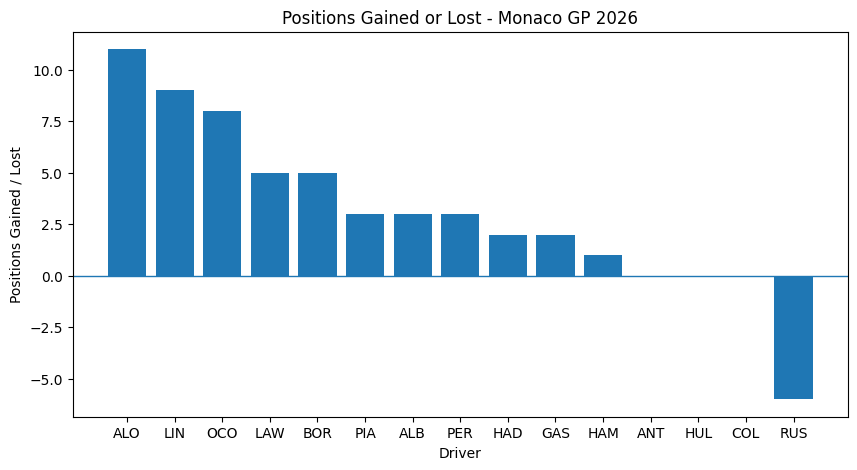

In [15]:
plt.figure(figsize=(10, 5))

plt.bar(
    positions_plot['Driver'],
    positions_plot['PositionsGained']
)

plt.axhline(0, linewidth=1)

plt.xlabel('Driver')
plt.ylabel('Positions Gained / Lost')
plt.title('Positions Gained or Lost - Monaco GP 2026')

plt.show()

Adesso vogliamo vedere come cambia il ritmo del pilota durante tutta la gara? Come pilota in questo caso scegliamo Antonelli

In [16]:
ant_laps = race.laps.pick_drivers('ANT')

In [17]:
ant_laps[
    ['LapNumber', 'LapTime', 'Compound', 'TyreLife', 'Stint', 'PitInTime', 'PitOutTime']
]

,LapNumber,LapTime,Compound,TyreLife,Stint,PitInTime,PitOutTime
200,1.0,0 days 00:01:22.525000,MEDIUM,1.0,1.0,NaT,NaT
201,2.0,0 days 00:01:17.653000,MEDIUM,2.0,1.0,NaT,NaT
202,3.0,0 days 00:01:16.996000,MEDIUM,3.0,1.0,NaT,NaT
203,4.0,0 days 00:01:17.048000,MEDIUM,4.0,1.0,NaT,NaT
204,5.0,0 days 00:01:16.661000,MEDIUM,5.0,1.0,NaT,NaT
...,...,...,...,...,...,...,...
273,74.0,0 days 00:01:13.958000,SOFT,10.0,5.0,NaT,NaT
274,75.0,0 days 00:01:14.008000,SOFT,11.0,5.0,NaT,NaT
275,76.0,0 days 00:01:13.481000,SOFT,12.0,5.0,NaT,NaT
276,77.0,0 days 00:01:13.728000,SOFT,13.0,5.0,NaT,NaT


In [18]:
ant_laps = ant_laps.copy()

ant_laps['LapTimeSeconds'] = (
    ant_laps['LapTime'].dt.total_seconds()
)

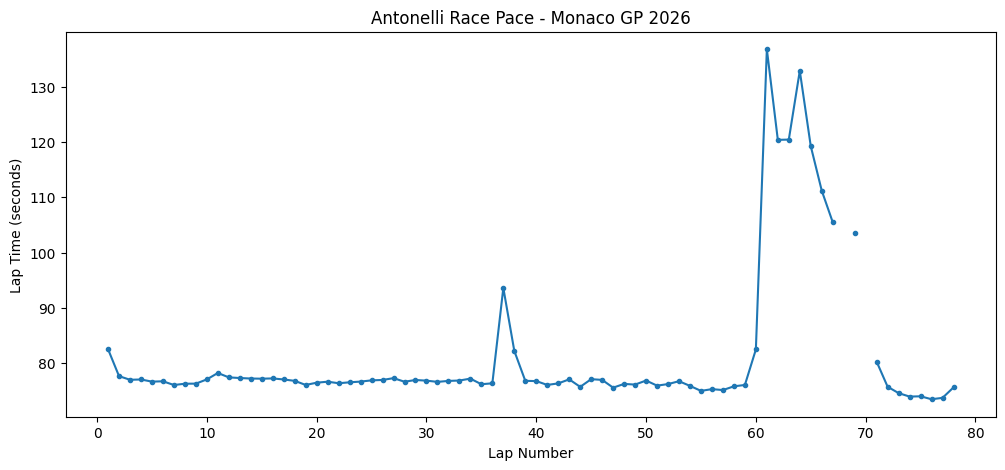

In [19]:
plt.figure(figsize=(12, 5))

plt.plot(
    ant_laps['LapNumber'],
    ant_laps['LapTimeSeconds'],
    marker='o',
    markersize=3
)

plt.xlabel('Lap Number')
plt.ylabel('Lap Time (seconds)')
plt.title('Antonelli Race Pace - Monaco GP 2026')

plt.show()

Un giro da 100 s rispetto a giri normali da 75 s non significa necessariamente che Antonelli abbia improvvisamente perso 25 secondi di performance.

Potrebbero esserci: pit stop; Safety Car/VSC; traffico; incidenti; in/out laps; altri eventi di gara.

Notiamo infatti che verso i giri 64/72 ci sono delle zone "vuote", andiamo ad investigarre quei giri in particolare

In [20]:
ant_laps.loc[
    ant_laps['LapNumber'].between(64, 72),
    ['LapNumber', 'LapTime', 'TrackStatus', 'PitInTime', 'PitOutTime']
]

,LapNumber,LapTime,TrackStatus,PitInTime,PitOutTime
263,64.0,0 days 00:02:12.838000,4,NaT,NaT
264,65.0,0 days 00:01:59.223000,412,NaT,NaT
265,66.0,0 days 00:01:51.182000,24,0 days 02:24:30.695000,NaT
266,67.0,0 days 00:01:45.482000,4,NaT,0 days 02:24:51.461000
267,68.0,NaT,451,0 days 02:28:25.488000,NaT
268,69.0,0 days 00:01:43.473000,14,NaT,0 days 03:04:19.751000
269,70.0,NaT,41,NaT,NaT
270,71.0,0 days 00:01:20.271000,12,NaT,NaT
271,72.0,0 days 00:01:15.737000,1,NaT,NaT


In [21]:
ant_laps.loc[
    ant_laps['LapTime'].isna(),
    ['LapNumber', 'LapTime', 'TrackStatus', 'PitInTime', 'PitOutTime']
]

,LapNumber,LapTime,TrackStatus,PitInTime,PitOutTime
267,68.0,NaT,451,0 days 02:28:25.488000,NaT
269,70.0,NaT,41,NaT,NaT


Tra i due time stamps passano 36 minuti, che non può possibilmente essere un pit stop, la gara è stata proprio interrotta.

Andiamo a vedere i Race COntrol Massages, per capire meglio la situazione

In [22]:
race.race_control_messages

,Time,Category,Message,Status,Flag,Scope,Sector,RacingNumber,Lap
0,2026-06-07 12:20:01,Flag,GREEN LIGHT - PIT EXIT OPEN,None,GREEN,Track,NaN,None,1
1,2026-06-07 12:22:10,Other,INCIDENT INVOLVING CAR 11 (PER) NOTED - FAILIN...,None,None,None,NaN,None,1
2,2026-06-07 12:25:25,Flag,YELLOW IN TRACK SECTOR 18,None,YELLOW,Sector,18.0,None,1
3,2026-06-07 12:26:04,Flag,CLEAR IN TRACK SECTOR 18,None,CLEAR,Sector,18.0,None,1
4,2026-06-07 12:30:01,Other,PIT EXIT CLOSED,None,None,None,NaN,None,1
...,...,...,...,...,...,...,...,...,...
260,2026-06-07 15:28:38,Other,ALL PASS HOLDERS MAY ACCESS THE PIT LANE,None,None,None,NaN,None,78
261,2026-06-07 15:29:56,Flag,DOUBLE YELLOW IN TRACK SECTOR 10,None,DOUBLE YELLOW,Sector,10.0,None,78
262,2026-06-07 15:30:22,Flag,YELLOW IN TRACK SECTOR 9,None,YELLOW,Sector,9.0,None,78
263,2026-06-07 15:33:10,Flag,CLEAR IN TRACK SECTOR 9,None,CLEAR,Sector,9.0,None,78


In [23]:
race.race_control_messages.columns

Index(['Time', 'Category', 'Message', 'Status', 'Flag', 'Scope', 'Sector',
       'RacingNumber', 'Lap'],
      dtype='object')

In [47]:
race.race_control_messages.loc[
    race.race_control_messages['Lap'].between(64, 72),
    ['Time', 'Lap', 'Category', 'Message', 'Flag', 'RacingNumber']
]

,Time,Lap,Category,Message,Flag,RacingNumber
206,2026-06-07 14:26:44,64,Other,FIA STEWARDS: PENALTY SERVED - 5 SECOND TIME P...,None,None
207,2026-06-07 14:28:23,64,Other,FIA STEWARDS: PENALTY SERVED - 5 SECOND TIME P...,None,None
208,2026-06-07 14:29:41,65,SafetyCar,SAFETY CAR IN THIS LAP,None,None
209,2026-06-07 14:30:34,65,Flag,TRACK CLEAR,CLEAR,None
210,2026-06-07 14:30:49,65,Flag,YELLOW IN TRACK SECTOR 18,YELLOW,None
211,2026-06-07 14:30:57,66,Flag,WAVED BLUE FLAG FOR CAR 43 (COL) TIMED AT 16:3...,BLUE,43
212,2026-06-07 14:31:18,66,SafetyCar,SAFETY CAR DEPLOYED,None,None
213,2026-06-07 14:31:37,66,Flag,DOUBLE YELLOW IN TRACK SECTOR 18,DOUBLE YELLOW,None
214,2026-06-07 14:31:38,66,Other,ALL CARS THROUGH THE PIT LANE,None,None
215,2026-06-07 14:32:10,66,Other,INCIDENT INVOLVING CAR 10 (GAS) NOTED - SPEEDI...,None,None


Da questi messaggi confermiamo quello che abbiamo ipotizzato prima, la gara è stata interrotta per un incidente di un pilota, e successivamente è stata ripresa dopo 36 minuti

Ora voglio vedere come Antonelli ha gestito i vari stint

In [25]:
ant_laps[
    ['LapNumber', 'Stint', 'Compound', 'TyreLife', 'LapTimeSeconds']
].head(30)

,LapNumber,Stint,Compound,TyreLife,LapTimeSeconds
200,1.0,1.0,MEDIUM,1.0,82.525
201,2.0,1.0,MEDIUM,2.0,77.653
202,3.0,1.0,MEDIUM,3.0,76.996
203,4.0,1.0,MEDIUM,4.0,77.048
204,5.0,1.0,MEDIUM,5.0,76.661
205,6.0,1.0,MEDIUM,6.0,76.723
206,7.0,1.0,MEDIUM,7.0,76.050
207,8.0,1.0,MEDIUM,8.0,76.284
208,9.0,1.0,MEDIUM,9.0,76.298
209,10.0,1.0,MEDIUM,10.0,77.067


In [26]:
ant_laps.groupby(
    ['Stint', 'Compound']
).agg(
    StartLap=('LapNumber', 'min'),
    EndLap=('LapNumber', 'max'),
    NumberOfLaps=('LapNumber', 'count')
)

,,StartLap,EndLap,NumberOfLaps
Stint,Compound,,,
1.0,MEDIUM,1.0,37.0,37
2.0,HARD,38.0,61.0,24
3.0,SOFT,62.0,66.0,5
4.0,SOFT,67.0,68.0,2
5.0,SOFT,69.0,78.0,10


In [27]:
ant_strategy = ant_laps.groupby(
    ['Stint', 'Compound']
).agg(
    StartLap=('LapNumber', 'min'),
    EndLap=('LapNumber', 'max'),
    NumberOfLaps=('LapNumber', 'count')
).reset_index()

In [28]:
ant_strategy

,Stint,Compound,StartLap,EndLap,NumberOfLaps
0,1.0,MEDIUM,1.0,37.0,37
1,2.0,HARD,38.0,61.0,24
2,3.0,SOFT,62.0,66.0,5
3,4.0,SOFT,67.0,68.0,2
4,5.0,SOFT,69.0,78.0,10


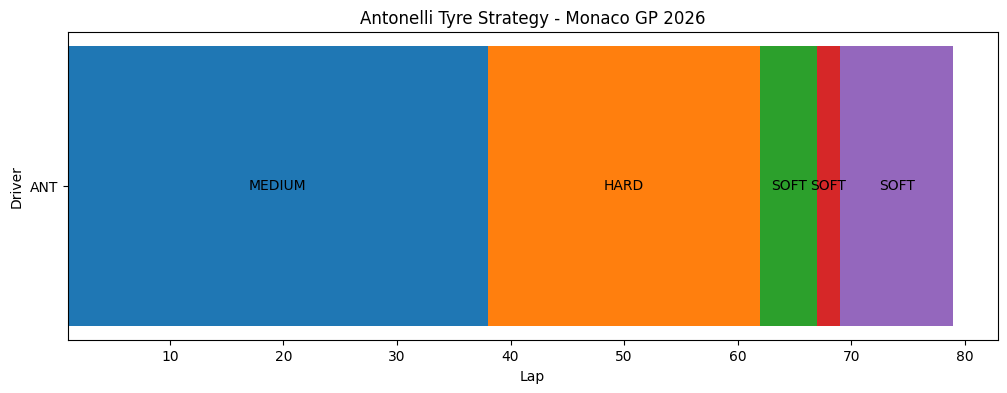

In [29]:
plt.figure(figsize=(12, 4))

for _, stint in ant_strategy.iterrows():

    plt.barh(
        'ANT',
        stint['NumberOfLaps'],
        left=stint['StartLap']
    )

    plt.text(
        stint['StartLap'] + stint['NumberOfLaps'] / 2,
        0,
        stint['Compound'],
        ha='center',
        va='center'
    )

plt.xlabel('Lap')
plt.ylabel('Driver')
plt.title('Antonelli Tyre Strategy - Monaco GP 2026')

plt.show()

Adesso aggiungiamo gli altri piloti, facciamo una tyre strategy chart dell'intera gara

In [30]:
race.laps

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:56:50.495000,NOR,1,0 days 00:01:30.629000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:39.379000,...,True,McLaren,0 days 00:55:19.645000,2026-06-07 13:03:11.904,12,8.0,False,,False,False
1,0 days 00:58:11.179000,NOR,1,0 days 00:01:20.684000,2.0,1.0,NaT,NaT,0 days 00:00:21.738000,0 days 00:00:37.534000,...,True,McLaren,0 days 00:56:50.495000,2026-06-07 13:04:42.754,1,8.0,False,,False,True
2,0 days 00:59:31.374000,NOR,1,0 days 00:01:20.195000,3.0,1.0,NaT,NaT,0 days 00:00:21.482000,0 days 00:00:37.614000,...,True,McLaren,0 days 00:58:11.179000,2026-06-07 13:06:03.438,1,8.0,False,,False,True
3,0 days 01:00:50.865000,NOR,1,0 days 00:01:19.491000,4.0,1.0,NaT,NaT,0 days 00:00:21.206000,0 days 00:00:37.169000,...,True,McLaren,0 days 00:59:31.374000,2026-06-07 13:07:23.633,1,8.0,False,,False,True
4,0 days 01:02:09.853000,NOR,1,0 days 00:01:18.988000,5.0,1.0,NaT,NaT,0 days 00:00:20.871000,0 days 00:00:36.960000,...,True,McLaren,0 days 01:00:50.865000,2026-06-07 13:08:43.124,1,8.0,False,,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1447,0 days 01:28:20.867000,BEA,87,0 days 00:01:19.137000,24.0,2.0,NaT,NaT,0 days 00:00:20.767000,0 days 00:00:37.212000,...,True,Haas F1 Team,0 days 01:27:01.730000,2026-06-07 13:34:53.989,1,20.0,True,TRACK LIMITS AT TURN 10 LAP 24,False,True
1448,0 days 01:29:39.550000,BEA,87,0 days 00:01:18.683000,25.0,2.0,NaT,NaT,0 days 00:00:20.809000,0 days 00:00:36.585000,...,True,Haas F1 Team,0 days 01:28:20.867000,2026-06-07 13:36:13.126,1,20.0,True,TRACK LIMITS AT TURN 10 LAP 25,False,True
1449,0 days 01:30:58.341000,BEA,87,0 days 00:01:18.791000,26.0,2.0,NaT,NaT,0 days 00:00:20.828000,0 days 00:00:37.028000,...,True,Haas F1 Team,0 days 01:29:39.550000,2026-06-07 13:37:31.809,1,20.0,False,,False,True
1450,0 days 01:32:16.964000,BEA,87,0 days 00:01:18.623000,27.0,2.0,NaT,NaT,0 days 00:00:20.669000,0 days 00:00:36.971000,...,True,Haas F1 Team,0 days 01:30:58.341000,2026-06-07 13:38:50.600,1,20.0,False,,False,True


In [31]:
race_strategy = race.laps.groupby(
    ['Driver', 'Stint', 'Compound']
).agg(
    StartLap=('LapNumber', 'min'),
    EndLap=('LapNumber', 'max'),
    NumberOfLaps=('LapNumber', 'count')
).reset_index()

In [32]:
race_strategy.head(20)

,Driver,Stint,Compound,StartLap,EndLap,NumberOfLaps
0,ALB,1.0,MEDIUM,1.0,43.0,43
1,ALB,2.0,SOFT,44.0,59.0,16
2,ALB,3.0,SOFT,60.0,65.0,6
3,ALB,4.0,SOFT,66.0,67.0,2
4,ALB,5.0,SOFT,68.0,68.0,1
5,ALB,6.0,SOFT,69.0,78.0,10
6,ALO,1.0,MEDIUM,1.0,3.0,3
7,ALO,2.0,SOFT,4.0,58.0,55
8,ALO,3.0,SOFT,59.0,59.0,1
9,ALO,4.0,SOFT,60.0,65.0,6


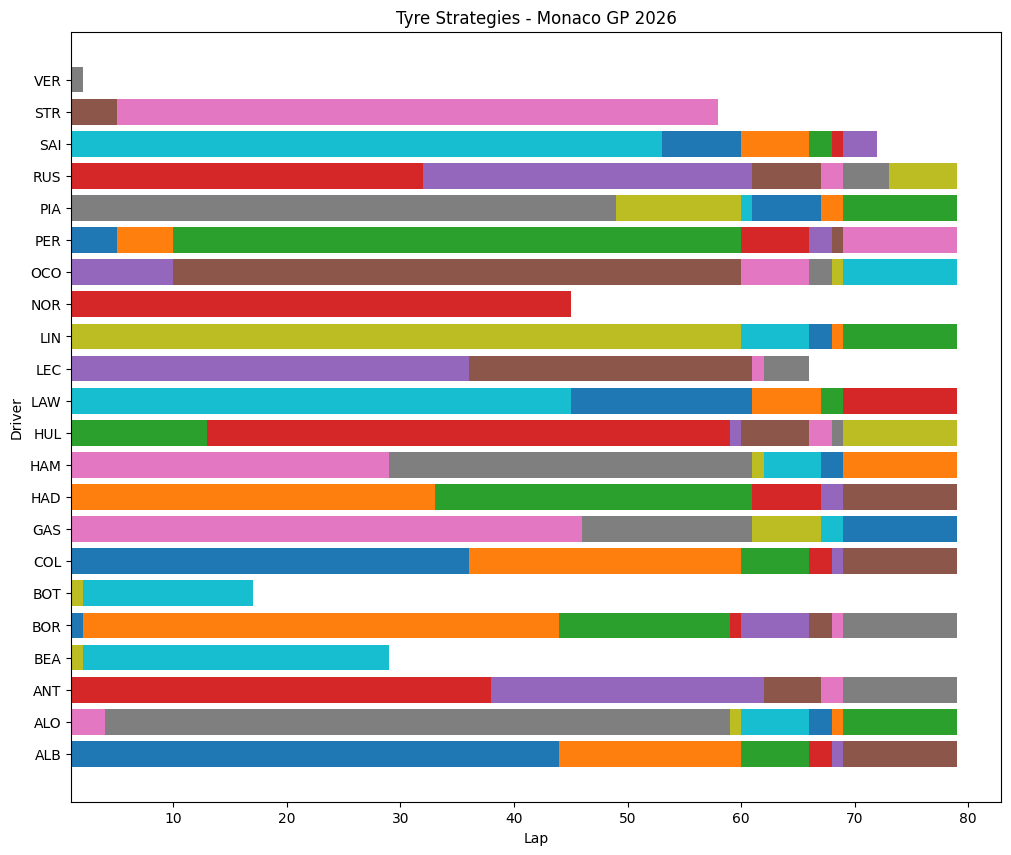

In [33]:
plt.figure(figsize=(12, 10))

for _, stint in race_strategy.iterrows():

    plt.barh(
        stint['Driver'],
        stint['NumberOfLaps'],
        left=stint['StartLap']
    )

plt.xlabel('Lap')
plt.ylabel('Driver')
plt.title('Tyre Strategies - Monaco GP 2026')

plt.show()

In [34]:
compound_colors = {
    'SOFT': 'red',
    'MEDIUM': 'gold',
    'HARD': 'white'
}

In [39]:
from matplotlib.patches import Patch

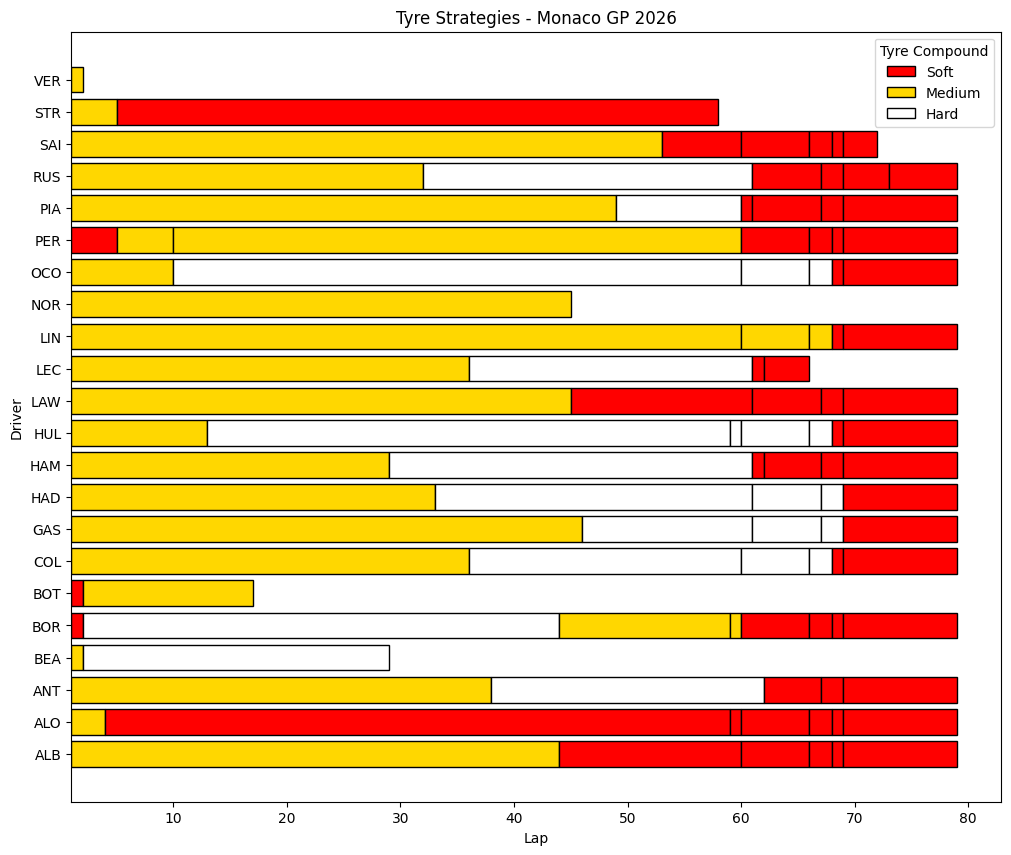

In [41]:
plt.figure(figsize=(12, 10))

for _, stint in race_strategy.iterrows():

    plt.barh(
        stint['Driver'],
        stint['NumberOfLaps'],
        left=stint['StartLap'],
        color=compound_colors[stint['Compound']],
        edgecolor='black'
    )

plt.xlabel('Lap')
plt.ylabel('Driver')
plt.title('Tyre Strategies - Monaco GP 2026')
legend_elements = [
    Patch(facecolor='red', edgecolor='black', label='Soft'),
    Patch(facecolor='gold', edgecolor='black', label='Medium'),
    Patch(facecolor='white', edgecolor='black', label='Hard')
]

plt.legend(
    handles=legend_elements,
    title='Tyre Compound'
)

plt.show()

Inizio adesso a vedere come cambia il lap time con l'aumentare di TyreLife

In [42]:
ant_stint1 = ant_laps[
    ant_laps['Stint'] == 1
].copy()

In [43]:
ant_stint1[
    ['LapNumber', 'LapTimeSeconds', 'TyreLife', 'Compound', 'TrackStatus']
]

,LapNumber,LapTimeSeconds,TyreLife,Compound,TrackStatus
200,1.0,82.525,1.0,MEDIUM,12
201,2.0,77.653,2.0,MEDIUM,1
202,3.0,76.996,3.0,MEDIUM,1
203,4.0,77.048,4.0,MEDIUM,1
204,5.0,76.661,5.0,MEDIUM,1
205,6.0,76.723,6.0,MEDIUM,1
206,7.0,76.050,7.0,MEDIUM,1
207,8.0,76.284,8.0,MEDIUM,1
208,9.0,76.298,9.0,MEDIUM,1
209,10.0,77.067,10.0,MEDIUM,1


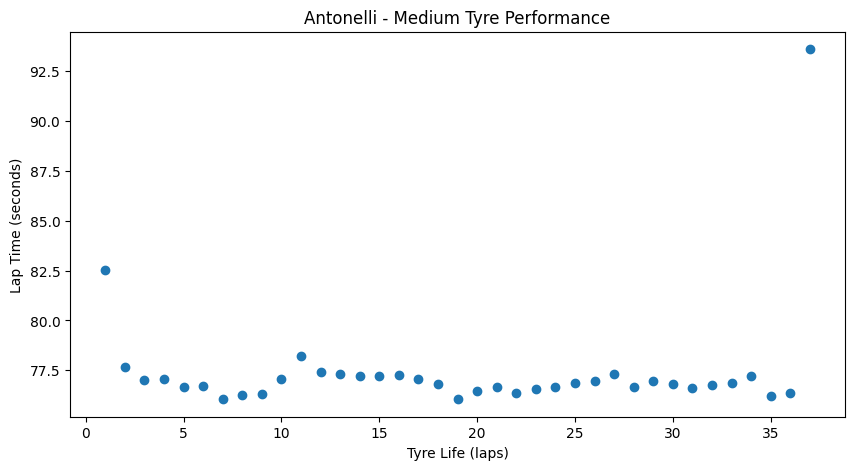

In [44]:
plt.figure(figsize=(10, 5))

plt.scatter(
    ant_stint1['TyreLife'],
    ant_stint1['LapTimeSeconds']
)

plt.xlabel('Tyre Life (laps)')
plt.ylabel('Lap Time (seconds)')
plt.title('Antonelli - Medium Tyre Performance')

plt.show()

Qui quello che mi chiedo è quando la gomma accumula giri, come cambia il tempo sul giro? Ma se vedo una tendenza crescente, non posso ancora dire che sia tutto tyre degradation, abbiamo bisogno di altre prove

Altre motivazioni potrebbero essere
gomma invecchia          → potenziale aumento del lap time
carburante diminuisce    → potenziale diminuzione del lap time
traffico                 → può aumentarlo
gestione gara            → può modificarlo
Safety Car / bandiere    → può alterarlo enormemente

In [48]:
ant_stint1[
    ['LapNumber', 'TyreLife', 'LapTimeSeconds', 'TrackStatus',
     'PitInTime', 'PitOutTime']
].sort_values(
    'LapTimeSeconds',
    ascending=False
).head(5)

,LapNumber,TyreLife,LapTimeSeconds,TrackStatus,PitInTime,PitOutTime
236,37.0,37.0,93.595,1,0 days 01:42:42.250000,NaT
200,1.0,1.0,82.525,12,NaT,NaT
210,11.0,11.0,78.223,1,NaT,NaT
201,2.0,2.0,77.653,1,NaT,NaT
211,12.0,12.0,77.430,1,NaT,NaT


In [49]:
ant_stint1.tail(5)[
    ['LapNumber', 'TyreLife', 'LapTimeSeconds',
     'TrackStatus', 'PitInTime']
]

,LapNumber,TyreLife,LapTimeSeconds,TrackStatus,PitInTime
232,33.0,33.0,76.862,1,NaT
233,34.0,34.0,77.201,1,NaT
234,35.0,35.0,76.191,1,NaT
235,36.0,36.0,76.356,1,NaT
236,37.0,37.0,93.595,1,0 days 01:42:42.250000


Ho identificato che questo outlier rappresenta il giro in cui Antonelli ha effettuato il pit stop, 

In [50]:
ant_stint1.head(5)[
    ['LapNumber', 'TyreLife', 'LapTimeSeconds',
     'TrackStatus', 'PitOutTime']
]

,LapNumber,TyreLife,LapTimeSeconds,TrackStatus,PitOutTime
200,1.0,1.0,82.525,12,NaT
201,2.0,2.0,77.653,1,NaT
202,3.0,3.0,76.996,1,NaT
203,4.0,4.0,77.048,1,NaT
204,5.0,5.0,76.661,1,NaT


Il giro 1 è particolare perché parte dalla griglia, non è un normale giro lanciato; inoltre il suo TrackStatus è diverso da 1. Quindi per studiare il normale race pace ha senso escluderlo.

In [51]:
ant_stint1_clean = ant_stint1[
    (ant_stint1['LapNumber'] > 1) &
    (ant_stint1['PitInTime'].isna()) &
    (ant_stint1['PitOutTime'].isna()) &
    (ant_stint1['TrackStatus'] == '1')
].copy()

In [52]:
print('Original laps:', len(ant_stint1))
print('Clean laps:', len(ant_stint1_clean))

Original laps: 37
Clean laps: 35


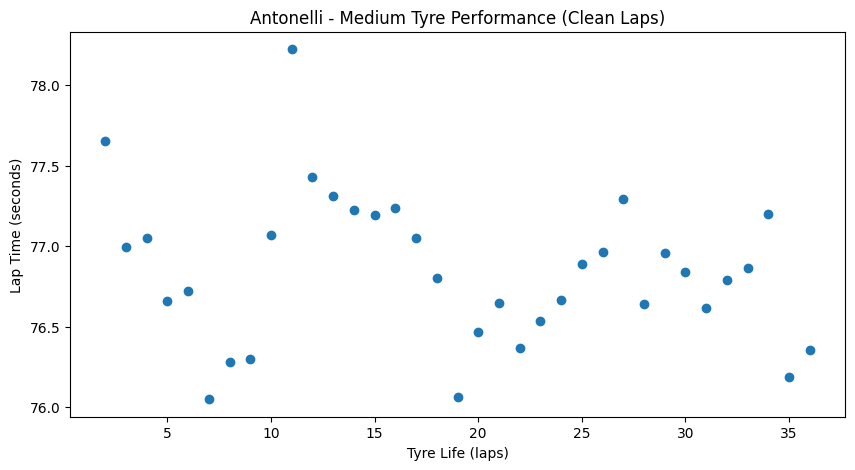

In [53]:
plt.figure(figsize=(10, 5))

plt.scatter(
    ant_stint1_clean['TyreLife'],
    ant_stint1_clean['LapTimeSeconds']
)

plt.xlabel('Tyre Life (laps)')
plt.ylabel('Lap Time (seconds)')
plt.title('Antonelli - Medium Tyre Performance (Clean Laps)')

plt.show()

In [54]:
slope, intercept = np.polyfit(
    ant_stint1_clean['TyreLife'],
    ant_stint1_clean['LapTimeSeconds'],
    1
)

print('Slope:', slope)
print('Intercept:', intercept)

Slope: -0.01000056022408944
Intercept: 77.03583921568628


In [55]:
trend = (
    slope * ant_stint1_clean['TyreLife']
    + intercept
)

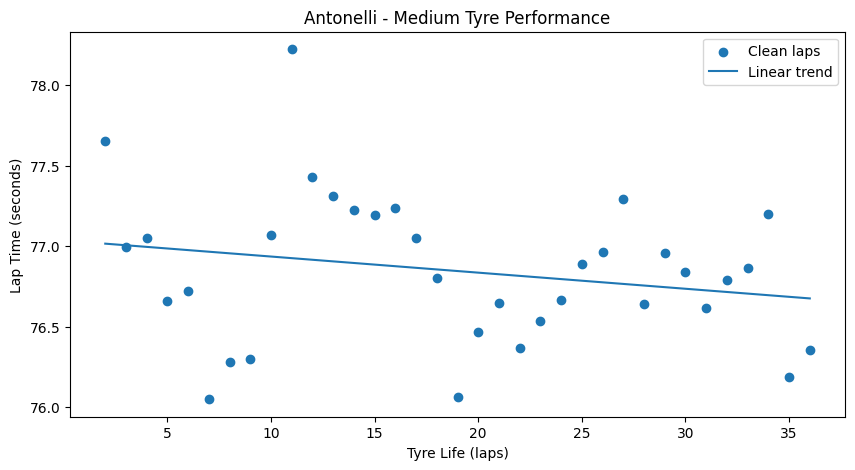

In [56]:
plt.figure(figsize=(10, 5))

plt.scatter(
    ant_stint1_clean['TyreLife'],
    ant_stint1_clean['LapTimeSeconds'],
    label='Clean laps'
)

plt.plot(
    ant_stint1_clean['TyreLife'],
    trend,
    label='Linear trend'
)

plt.xlabel('Tyre Life (laps)')
plt.ylabel('Lap Time (seconds)')
plt.title('Antonelli - Medium Tyre Performance')

plt.legend()
plt.show()

Plottando una regressione lineare ho ottenuto come risultato: 
\[ LapTime = 77.036 - 0.0100 x TyreLife
\]
Quindi per ogni giro aggiuntivo di vita della gomma, il lap time stimato dalla retta diminuisce di circa 0.01 secondi, cioè circa 10 millisecondi per giro

In [58]:
ss_res = np.sum(
    (ant_stint1_clean['LapTimeSeconds'] - trend) ** 2
)

ss_tot = np.sum(
    (ant_stint1_clean['LapTimeSeconds']
     - ant_stint1_clean['LapTimeSeconds'].mean()) ** 2
)

r_squared = 1 - (ss_res / ss_tot)

print('R²:', r_squared)

R²: 0.04926844589931867


Significa che questa semplice relazione lineare con TyreLife spiega soltanto circa il 4,9% della variabilità dei lap time nei giri che abbiamo selezionato.

Chiudiamo ora con l'analisi di Antonelli, adesso facciamo un analisi più interessante: Quali piloti hanno avuto il race pace migliore e più consistente?

usando la stessa logica applicata al caso di Antonelli nella gestione degli outlier creiamo un dataset pulito.


In [59]:
clean_race_laps = race.laps[
    (race.laps['PitInTime'].isna()) &
    (race.laps['PitOutTime'].isna()) &
    (race.laps['TrackStatus'] == '1') &
    (race.laps['LapNumber'] > 1)
].copy()


In [61]:
clean_race_laps['LapTimeSeconds'] = (
    clean_race_laps['LapTime'].dt.total_seconds()
)

quindi teniamo ✓ niente in-lap
✓ niente out-lap
✓ normale track status
✓ niente lap 1

In [62]:
clean_race_laps.groupby('Driver').size().sort_values(
    ascending=False
)

Driver
ANT    63
LIN    63
HAM    63
PIA    62
GAS    62
HAD    62
ALB    61
ALO    61
OCO    61
LAW    61
HUL    61
COL    61
RUS    60
BOR    59
PER    58
LEC    56
SAI    54
STR    53
NOR    42
BEA    25
BOT    13
dtype: int64

In [63]:
finished_driver_names = race_results.loc[
    race_results['Status'] == 'Finished',
    'Driver'
]

In [64]:
finished_clean_laps = clean_race_laps[
    clean_race_laps['Driver'].isin(finished_driver_names)
].copy()

In [65]:
race_pace = finished_clean_laps.groupby('Driver').agg(
    MedianLapTime=('LapTimeSeconds', 'median'),
    MeanLapTime=('LapTimeSeconds', 'mean'),
    StdLapTime=('LapTimeSeconds', 'std'),
    CleanLaps=('LapTimeSeconds', 'count')
).reset_index()

In [66]:
race_pace = race_pace.sort_values('MedianLapTime')

race_pace

,Driver,MedianLapTime,MeanLapTime,StdLapTime,CleanLaps
2,ANT,76.6440,76.356127,0.940106,63
7,HAM,77.0050,76.883365,0.788345,63
6,HAD,77.8375,77.985274,0.908817,62
14,RUS,77.8980,77.939900,1.166613,60
13,PIA,78.2250,78.078839,1.038719,62
5,GAS,78.3860,78.279113,1.004461,62
9,LAW,78.7000,78.544820,1.102622,61
3,BOR,78.8970,79.641153,1.984856,59
0,ALB,79.1310,79.360820,1.475984,61
10,LIN,79.2030,79.565667,1.594827,63


Media e mediana non raccontano sempre esattamente la stessa storia. Guarda Bortoleto: ha la media nettamente più alta rispetto alla mediana, il che indica che ha fatto diversi giri più lenti che hanno alzato la media.

In [68]:
best_median = race_pace['MedianLapTime'].min()

race_pace['GapToBestMedian'] = (
    race_pace['MedianLapTime'] - best_median
)

In [69]:
race_pace[
    ['Driver', 'MedianLapTime', 'GapToBestMedian']
]

,Driver,MedianLapTime,GapToBestMedian
2,ANT,76.6440,0.0000
7,HAM,77.0050,0.3610
6,HAD,77.8375,1.1935
14,RUS,77.8980,1.2540
13,PIA,78.2250,1.5810
5,GAS,78.3860,1.7420
9,LAW,78.7000,2.0560
3,BOR,78.8970,2.2530
0,ALB,79.1310,2.4870
10,LIN,79.2030,2.5590


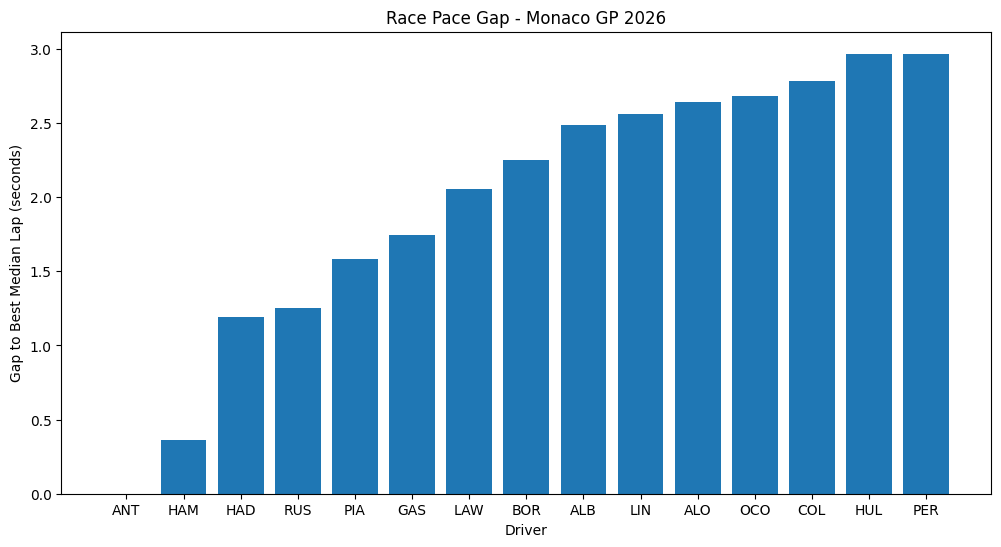

In [70]:
plt.figure(figsize=(12, 6))

plt.bar(
    race_pace['Driver'],
    race_pace['GapToBestMedian']
)

plt.xlabel('Driver')
plt.ylabel('Gap to Best Median Lap (seconds)')
plt.title('Race Pace Gap - Monaco GP 2026')

plt.show()

Adesso andiamo a vedere la consistency


In [71]:
driver_order = race_pace['Driver'].tolist()

driver_order

['ANT',
 'HAM',
 'HAD',
 'RUS',
 'PIA',
 'GAS',
 'LAW',
 'BOR',
 'ALB',
 'LIN',
 'ALO',
 'OCO',
 'COL',
 'HUL',
 'PER']

In [72]:
lap_times_by_driver = [
    finished_clean_laps.loc[
        finished_clean_laps['Driver'] == driver,
        'LapTimeSeconds'
    ]
    for driver in driver_order
]

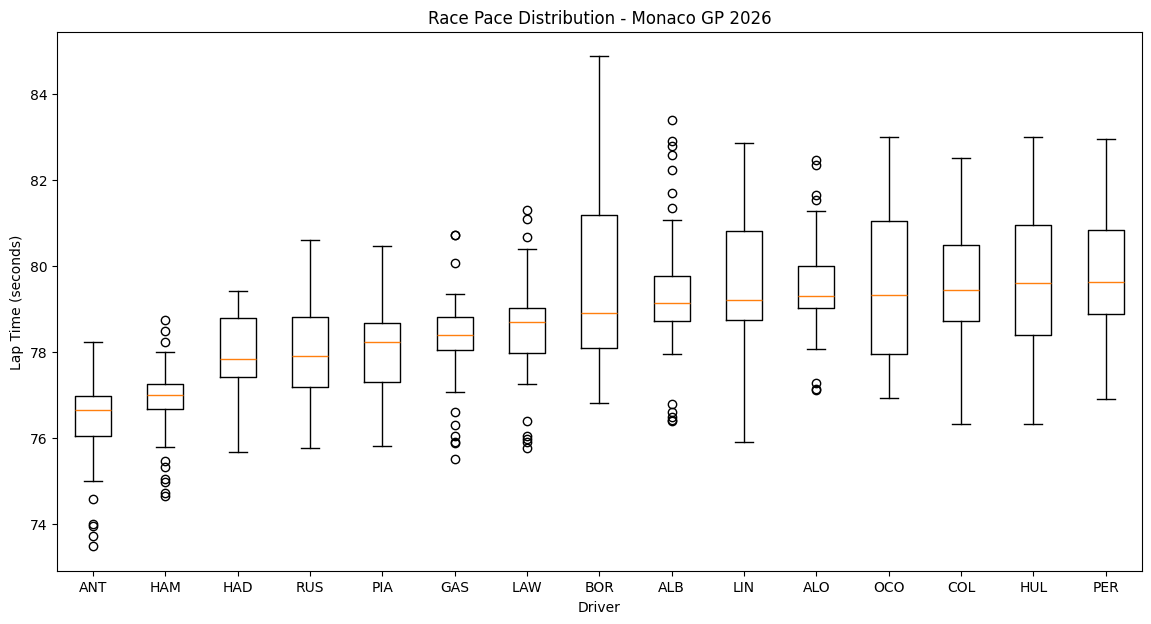

In [73]:
plt.figure(figsize=(14, 7))

plt.boxplot(
    lap_times_by_driver,
    tick_labels=driver_order,
    showfliers=True
)

plt.xlabel('Driver')
plt.ylabel('Lap Time (seconds)')
plt.title('Race Pace Distribution - Monaco GP 2026')

plt.show()

Facciamo un grafico pace vs consistency.  Mettiamo:
\[
x = MedianLapTime
\]
\[
y = StdLapTime
\]
Quindi più a sinistra = race pace più basso, mentre più in basso = lap time meno variabili.

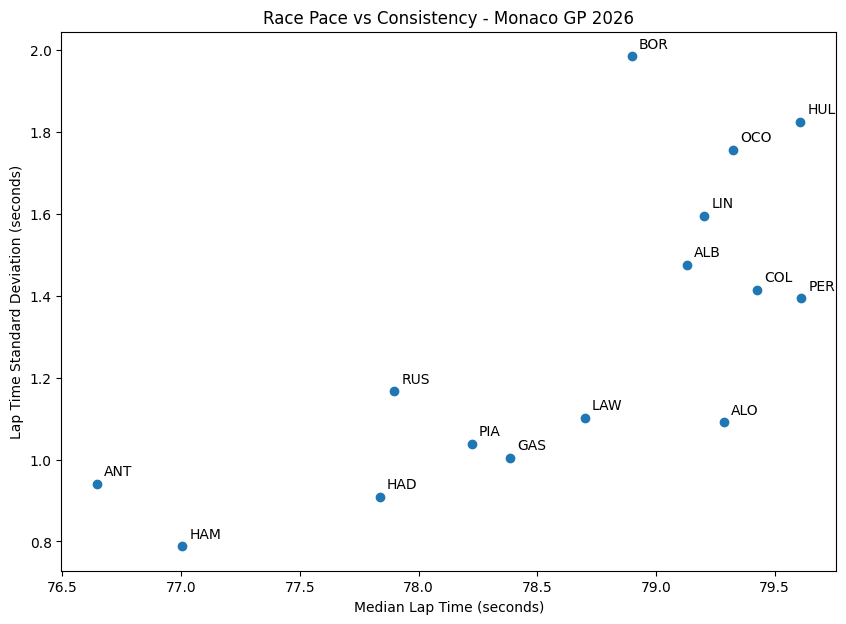

In [74]:
plt.figure(figsize=(10, 7))

plt.scatter(
    race_pace['MedianLapTime'],
    race_pace['StdLapTime']
)

for _, driver in race_pace.iterrows():
    plt.text(
        driver['MedianLapTime'] + 0.03,
        driver['StdLapTime'] + 0.02,
        driver['Driver']
    )

plt.xlabel('Median Lap Time (seconds)')
plt.ylabel('Lap Time Standard Deviation (seconds)')
plt.title('Race Pace vs Consistency - Monaco GP 2026')

plt.show()

Il quadrante concettualmente più interessante è quello in basso a sinistra: lap time mediano più basso + deviazione standard più bassa. Lì troviamo soprattutto ANT, HAM e HAD. Hamilton, per esempio, ha una dispersione inferiore ad Antonelli, anche se Antonelli ha una mediana più bassa. Quindi il grafico separa bene i due concetti: pace sull'asse X e consistency sull'asse Y.
Un altro esempio interessante è quello di Bortoleto, la sua mediana non è tra le più alte in assoluto, ma ha una deviazione standard vicina a 2 s. Quindi il tratto distintivo dei suoi clean laps è soprattutto la variabilità